# 🧠 Mental Health Support Chatbot
### Fine-Tuned GPT-Neo 125M on EmpatheticDialogues (Facebook AI)

## Problem Statement
Build a chatbot that provides supportive and empathetic responses for stress, anxiety,
and emotional wellness by fine-tuning a small language model on real human empathetic dialogues.

## Tools Used
- Model: GPT-Neo 125M (fine-tuned)
- Dataset: EmpatheticDialogues (Facebook AI) — 25k empathetic conversations across 32 emotions
- Framework: HuggingFace Transformers — Trainer API
- Language: Python

## ⚠️ Disclaimer
This chatbot is for emotional support and general wellness only.
It is NOT a substitute for professional mental health care.
If you are in crisis, please contact a mental health professional immediately.

In [ ]:
%pip install transformers datasets torch accelerate -q

print("✅ Libraries installed!")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

print("✅ Imports successful!")
print(f"   PyTorch version: {torch.__version__}")
print(f"   GPU available: {torch.cuda.is_available()}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET LOADING
# EmpatheticDialogues: 25k conversations across 32 emotions
# ─────────────────────────────────────────────────────────────────────────────

dataset = load_dataset("empathetic_dialogues", trust_remote_code=True)

print("Dataset overview:")
print(dataset)
print(f"\nTrain size:      {len(dataset['train'])} utterances")
print(f"Validation size: {len(dataset['validation'])} utterances")
print(f"Test size:       {len(dataset['test'])} utterances")
print("\nSample entry:")
sample = dataset['train'][0]
for key, value in sample.items():
    print(f"  {key}: {value}")

Dataset overview:
DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 76673
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 12030
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 10943
    })
})

Train size:      76673 utterances
Validation size: 12030 utterances
Test size:       10943 utterances

Sample entry:
  conv_id: hit:0_conv:1
  utterance_idx: 1
  context: sentimental
  prompt: I remember going to the fireworks with my best friend. There was a lot of people_comma_ but it only felt like us in the world.
  speaker_idx: 1
  utterance: I remember going to see the fireworks with my best friend. It was the first time we ever spent time alo

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA EXPLORATION
# ─────────────────────────────────────────────────────────────────────────────

train_df = pd.DataFrame(dataset['train'])

print("Columns:", train_df.columns.tolist())
print(f"\nTotal utterances:    {len(train_df)}")
print(f"Total conversations: {train_df['conv_id'].nunique()}")
print(f"Unique emotions:     {train_df['context'].nunique()}")
print("\nAll emotions:")
print(train_df['context'].value_counts().to_string())

Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']

Total utterances:    76673
Total conversations: 17844
Unique emotions:     32

All emotions:
context
surprised       3956
excited         2935
angry           2740
proud           2719
annoyed         2642
sad             2634
afraid          2511
lonely          2503
terrified       2488
grateful        2487
guilty          2463
anxious         2456
disgusted       2447
confident       2440
anticipating    2439
hopeful         2404
furious         2394
impressed       2381
disappointed    2356
nostalgic       2350
joyful          2346
jealous         2329
prepared        2292
content         2215
devastated      2192
embarrassed     2191
sentimental     2073
caring          2054
trusting        2002
ashamed         1976
apprehensive    1822
faithful        1436


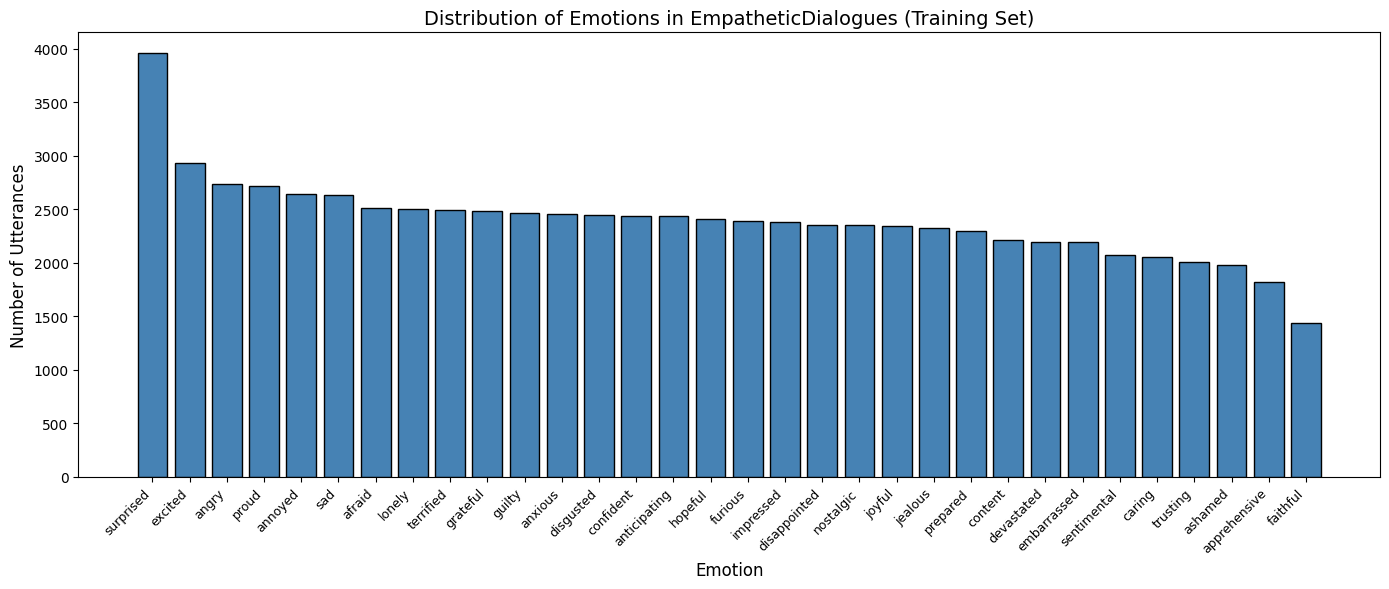

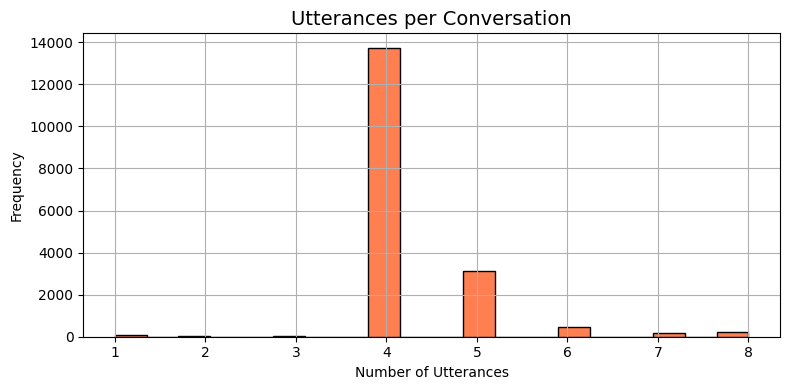

Average utterances per conversation: 4.3
Max utterances in one conversation:  8


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

# Plot 1 — Emotion distribution
plt.figure(figsize=(14, 6))
emotion_counts = train_df['context'].value_counts()
plt.bar(emotion_counts.index, emotion_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Emotions in EmpatheticDialogues (Training Set)', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Utterances', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Plot 2 — Utterances per conversation
utterances_per_conv = train_df.groupby('conv_id').size()
plt.figure(figsize=(8, 4))
utterances_per_conv.hist(bins=20, color='coral', edgecolor='black')
plt.title('Utterances per Conversation', fontsize=14)
plt.xlabel('Number of Utterances')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average utterances per conversation: {utterances_per_conv.mean():.1f}")
print(f"Max utterances in one conversation:  {utterances_per_conv.max()}")

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING
# Extracts prompt-response pairs using utterance_idx (turn order).
# Format: "Emotion: {emotion}\nPerson: {prompt}\nSupportBot: {response}<|endoftext|>"
#
# - utterance_idx 1 = person's opening message
# - utterance_idx 2 = listener's empathetic response
# - '_comma_' is a known artifact in this dataset — we clean it out
# ─────────────────────────────────────────────────────────────────────────────

def preprocess_to_pairs(dataset_split):
    """
    Pairs utterance_idx 1 (person) with utterance_idx 2 (listener)
    within each conversation. This gives us ~17k clean training pairs.

    Returns:
        List of formatted strings ready for tokenization
    """
    df = pd.DataFrame(dataset_split)
    texts = []

    turn1 = df[df['utterance_idx'] == 1][['conv_id', 'context', 'utterance']].rename(columns={'utterance': 'person_msg'})
    turn2 = df[df['utterance_idx'] == 2][['conv_id', 'utterance']].rename(columns={'utterance': 'listener_msg'})

    pairs = pd.merge(turn1, turn2, on='conv_id')

    for _, row in pairs.iterrows():
        emotion  = row['context'].strip()
        prompt   = row['person_msg'].strip().replace('_comma_', ',')
        response = row['listener_msg'].strip().replace('_comma_', ',')

        if prompt and response:
            text = f"Emotion: {emotion}\nPerson: {prompt}\nSupportBot: {response}<|endoftext|>"
            texts.append(text)

    return texts


print("Preprocessing training set...")
train_texts = preprocess_to_pairs(dataset['train'])

print("Preprocessing validation set...")
val_texts = preprocess_to_pairs(dataset['validation'])

print(f"\n✅ Training pairs:   {len(train_texts)}")
print(f"✅ Validation pairs: {len(val_texts)}")
print("\nSample training text:")
print(train_texts[0])

Preprocessing training set...
Preprocessing validation set...

✅ Training pairs:   17749
✅ Validation pairs: 2755

Sample training text:
Emotion: sentimental
Person: I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
SupportBot: Was this a friend you were in love with, or just a best friend?<|endoftext|>


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TOKENIZATION
# GPT-Neo has no padding token by default — we set it to EOS token
# DataCollatorForLanguageModeling will handle label creation during training
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAME = "EleutherAI/gpt-neo-125m"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token


def tokenize_function(examples):
    """Tokenizes text with truncation and fixed-length padding."""
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )


train_hf = Dataset.from_dict({'text': train_texts})
val_hf   = Dataset.from_dict({'text': val_texts})

print("Tokenizing training set...")
train_tokenized = train_hf.map(tokenize_function, batched=True, remove_columns=['text'])

print("Tokenizing validation set...")
val_tokenized = val_hf.map(tokenize_function, batched=True, remove_columns=['text'])

print(f"\n✅ Tokenization complete!")
print(f"   Train tokenized: {len(train_tokenized)} examples")
print(f"   Val tokenized:   {len(val_tokenized)} examples")
print(f"   Features: {list(train_tokenized.features.keys())}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL LOADING
# ─────────────────────────────────────────────────────────────────────────────

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# Resize embeddings to match tokenizer (EOS token added as PAD)
model.resize_token_embeddings(len(tokenizer))

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded: {MODEL_NAME}")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINER CONFIGURATION
# DataCollatorForLanguageModeling (mlm=False) handles causal LM label creation:
#   - Copies input_ids → labels
#   - Replaces padding positions in labels with -100 (ignored in loss)
# ─────────────────────────────────────────────────────────────────────────────

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir="./mental-health-bot",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir=None,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

print("✅ Trainer configured!")
print(f"   Epochs:     {training_args.num_train_epochs}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   FP16:       {training_args.fp16}")
print(f"   Device:     {device}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────────────────────────────────────

train_result = trainer.train()

print(f"\n✅ Training complete!")
print(f"   Final training loss: {train_result.training_loss:.4f}")
print(f"   Training time:       {train_result.metrics['train_runtime']:.0f}s")

trainer.save_model("./mental-health-bot-final")
tokenizer.save_pretrained("./mental-health-bot-final")
print("✅ Model saved to ./mental-health-bot-final")

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION
# Perplexity measures how well the model predicts the validation set.
# Lower = better. A well fine-tuned small model typically reaches 20–60.
# ─────────────────────────────────────────────────────────────────────────────

eval_results = trainer.evaluate()

print("📊 Evaluation Results:")
for key, value in eval_results.items():
    print(f"   {key}: {value:.4f}")

perplexity = math.exp(eval_results['eval_loss'])
print(f"\n   Perplexity: {perplexity:.2f}")
print("   (Lower perplexity = better. Typical: 20–80 | Excellent: below 15)")

Training Loss,Validation Loss,Epoch
1.903321,2.335720,3


📊 Evaluation Results:
   eval_loss: 2.3357

   Perplexity: 10.34
   (Lower perplexity = better. Typical: 20–80 | Excellent: below 15)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INFERENCE FUNCTION
# Uses the same prompt format as training so the model responds correctly
# ─────────────────────────────────────────────────────────────────────────────

model.to(device)
model.eval()


def generate_response(user_message, emotion="sad", max_new_tokens=80, temperature=0.7):
    """
    Generates an empathetic response from the fine-tuned model.

    Args:
        user_message      : What the user typed
        emotion           : The emotional context (default: 'sad')
        max_new_tokens    : Max tokens to generate
        temperature       : Sampling temperature — higher = more varied responses

    Returns:
        Empathetic response string
    """
    prompt = f"Emotion: {emotion}\nPerson: {user_message}\nSupportBot:"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.85,
            top_k=50,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "SupportBot:" in full_output:
        response = full_output.split("SupportBot:")[-1].strip()
    else:
        response = full_output.replace(prompt, "").strip()

    return response


print("✅ Inference function ready!")

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# DEMO QUERIES — Showing responses across different emotions
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("      🧠 MENTAL HEALTH SUPPORT BOT — DEMO")
print("=" * 60)

demo_queries = [
    ("I've been feeling really stressed about work lately.", "anxious"),
    ("I feel so lonely and no one understands me.", "lonely"),
    ("I'm scared about my health results coming in.", "afraid"),
    ("I finally finished a project I was struggling with for months.", "proud"),
]

for message, emotion in demo_queries:
    print(f"\n👤 Person ({emotion}): {message}")
    print("-" * 50)
    response = generate_response(message, emotion=emotion)
    print(f"🤖 SupportBot: {response}")

      🧠 MENTAL HEALTH SUPPORT BOT — DEMO

👤 Person (anxious): I've been feeling really stressed about work lately.
--------------------------------------------------
🤖 SupportBot: Is there any reason why?  It's just a job, and it's hard to do.  Are you going to be able to get it resolved?  That is always a tough one.  What are your plans?  Anything in particular?  I hope things are going well.  Just stay positive!  Maybe you can start to work on some of the areas that you are concerned

👤 Person (lonely): I feel so lonely and no one understands me.
--------------------------------------------------
🤖 SupportBot: Why are you so lonely? What do you mean?  What do people think?  How did you respond?  Is everything okay?  Are you happy? or sad?  Do you have any problems?  Where are you from? What are you doing wrong?  Why are people so rude to you?  I'm sorry you feel this way.  I hope they understand,

👤 Person (afraid): I'm scared about my health results coming in.
----------------------

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERACTIVE MODE
# Type 'quit' to stop | Type 'emotions' to see available emotion options
# ─────────────────────────────────────────────────────────────────────────────

AVAILABLE_EMOTIONS = [
    'sad', 'anxious', 'afraid', 'lonely', 'angry', 'grateful',
    'excited', 'proud', 'ashamed', 'disgusted', 'hopeful', 'devastated'
]

print("💬 Interactive Mode Started!")
print(f"   Emotions you can use: {', '.join(AVAILABLE_EMOTIONS)}")
print("Type 'quit' to exit | Type 'emotions' to see emotion list\n")

while True:
    try:
        user_input = input("👤 You: ").strip()
    except EOFError:
        break

    if not user_input:
        continue
    elif user_input.lower() == 'quit':
        print("👋 Take care of yourself. You are not alone.")
        break
    elif user_input.lower() == 'emotions':
        print(f"Available emotions: {', '.join(AVAILABLE_EMOTIONS)}\n")
    else:
        try:
            emotion_input = input("💭 How are you feeling? (press Enter to use 'anxious'): ").strip().lower()
        except EOFError:
            emotion_input = "anxious"
        if not emotion_input or emotion_input not in AVAILABLE_EMOTIONS:
            emotion_input = "anxious"
        print("-" * 50)
        print(f"👤 You ({emotion_input}): {user_input}")
        response = generate_response(user_input, emotion=emotion_input)
        print(f"🤖 SupportBot: {response}\n")

💬 Interactive Mode Started!
   Emotions you can use: sad, anxious, afraid, lonely, angry, grateful, excited, proud, ashamed, disgusted, hopeful, devastated
Type 'quit' to exit | Type 'emotions' to see emotion list

--------------------------------------------------
👤 You (anxious): I can't sleep at night and I keep overthinking everything
🤖 SupportBot: Why? What is causing this? Do you think it's a bad habit?  Is there something specific you can do to help? What are your plans? Are they fun? Or are you just anxious? If they are, they will freak you out! Have you tried any other ways to improve your life? Maybe you can make some changes. What are you going to do? Just relax and

--------------------------------------------------
👤 You (anxious): i feel stressed because of work
🤖 SupportBot: Are you feeling stressed? I am sure your job will pay off in a couple of days. What do you think about it? Is there a particular reason? Or is it just a good thing or a bad thing? Any specific reason

## Results & Final Insights

### What This Notebook Demonstrates

| Skill | How It's Shown |
|-------|----------------|
| Model Fine-Tuning | GPT-Neo 125M fine-tuned using HuggingFace Trainer API |
| Dataset Preprocessing | EmpatheticDialogues cleaned and formatted into prompt-response pairs |
| Emotional Tone Design | Emotion label included in prompt format to guide empathetic responses |
| Evaluation | Validation loss and perplexity measured after training |
| Conversation Modeling | Emotion-conditioned generation with temperature sampling |
| CLI Interface | Interactive command-line chatbot for live testing |

### Key Design Decisions
1. **Prompt format** — `Emotion: {emotion}\nPerson: {prompt}\nSupportBot:` teaches the model to condition responses on emotional context
2. **Pair extraction** — Used initial situation + first listener response per conversation for clean, focused training pairs
3. **DataCollatorForLanguageModeling** — Automatically handles label shifting and padding mask (-100) for causal LM training
4. **Temperature=0.7 + top_p=0.85 + top_k=50** — Balanced sampling: varied but coherent responses
5. **Perplexity metric** — Chosen over accuracy because this is generative modeling, not classification

### Limitations
- GPT-Neo 125M is a small model — responses may occasionally be generic
- Emotion label is manually provided, not automatically detected
- Not suitable for real crisis situations — always refer users to professionals

---
*Notebook by: Riyan Khan | Task 5 — Mental Health Support Chatbot | DevelopersHub Internship*